In [4]:
import kagglehub
import os

# Install kagglehub if not already installed
%pip install kagglehub

# Download and extract the dataset, 'path' will be the root directory of the extracted dataset
dataset_root_path = kagglehub.dataset_download("andrewmvd/car-plate-detection")

print(f"Dataset downloaded and extracted to: {dataset_root_path}")

Using Colab cache for faster access to the 'car-plate-detection' dataset.
Dataset downloaded and extracted to: /kaggle/input/car-plate-detection


Found 433 images in /kaggle/input/car-plate-detection/images


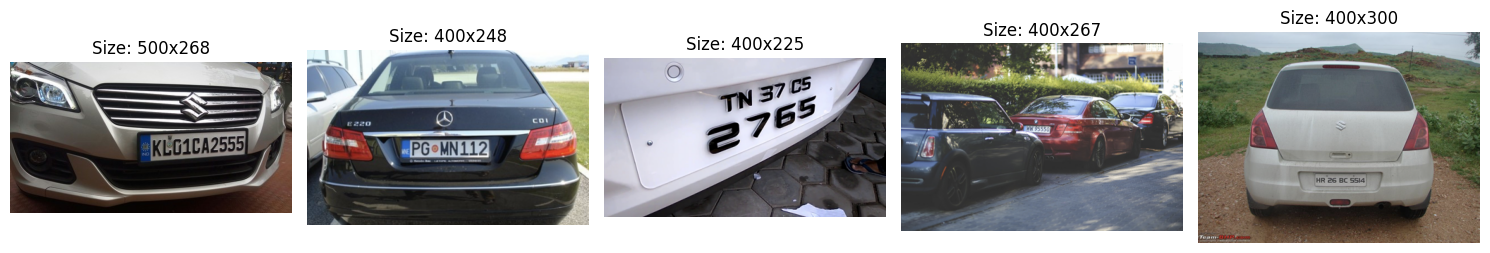

In [5]:
import os
import glob
import cv2
import matplotlib.pyplot as plt

# Assuming images are in a subdirectory named 'images'
image_dir = os.path.join(dataset_root_path, 'images')

# Get a list of all image files (assuming .png format based on ls -R output)
image_files = glob.glob(os.path.join(image_dir, '*.png'))
image_files.sort() # Sort to ensure consistent order

print(f"Found {len(image_files)} images in {image_dir}")

# Display the first 5 images
if len(image_files) == 0:
    print("No images found. Please check the directory structure and file types.")
else:
    plt.figure(figsize=(15, 10))
    for i, img_path in enumerate(image_files[:5]):
        img = cv2.imread(img_path)
        if img is not None:
            # OpenCV loads images in BGR, matplotlib expects RGB
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            height, width, _ = img.shape

            plt.subplot(1, 5, i + 1)
            plt.imshow(img_rgb)
            plt.title(f"Size: {width}x{height}")
            plt.axis('off')
        else:
            print(f"Could not load image: {img_path}")
    plt.tight_layout()
    plt.show()

## Load and Preprocess an Example Image

Load a single image and apply initial preprocessing steps such as resizing to a common dimension (e.g., 224x224 for VGG), and normalizing pixel values. This step will demonstrate the process on one image.


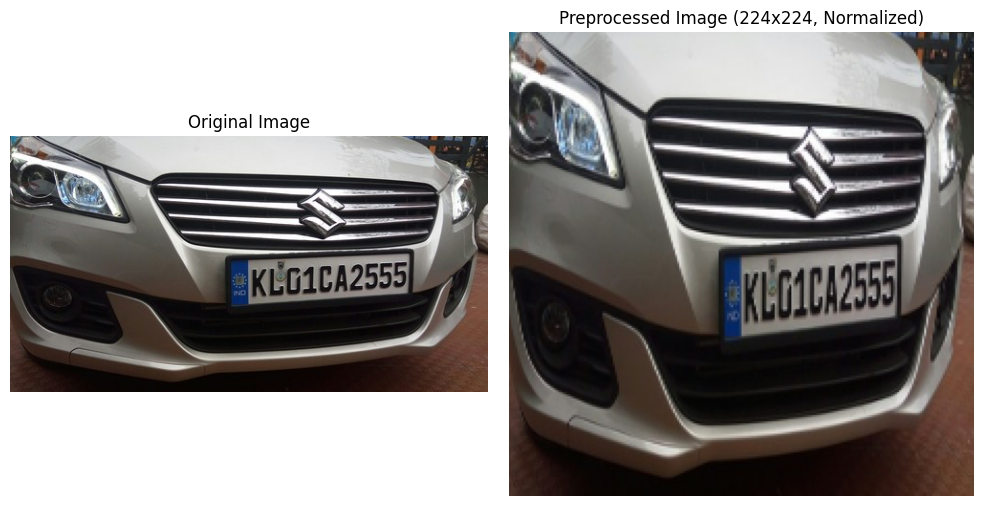

Original image shape: (268, 500, 3)
Resized image shape: (224, 224, 3)
Normalized image shape: (224, 224, 3)
Normalized image pixel value range: [0.00, 1.00]


In [6]:
import numpy as np

# 1. Select the first image as an example
example_img_path = image_files[0]

# 2. Load the example image and convert from BGR to RGB
original_img = cv2.imread(example_img_path)
original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# 3. Resize the image to 224x224 pixels
target_size = (224, 224)
resized_img = cv2.resize(original_img_rgb, target_size)

# 4. Normalize the pixel values to the range [0, 1]
normalized_img = resized_img.astype(np.float32) / 255.0

# 5. Display original and preprocessed images side by side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(normalized_img)
plt.title(f'Preprocessed Image ({target_size[0]}x{target_size[1]}, Normalized)')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Original image shape: {original_img_rgb.shape}")
print(f"Resized image shape: {resized_img.shape}")
print(f"Normalized image shape: {normalized_img.shape}")
print(f"Normalized image pixel value range: [{normalized_img.min():.2f}, {normalized_img.max():.2f}]")

## Define Preprocessing Function

Create a Python function that encapsulates all the necessary preprocessing steps (resizing, normalization, etc.) for a given input image, making it suitable for a CNN or VGG model.


In [7]:
def preprocess_image(image_path, target_size=(224, 224)):
    """
    Loads an image, converts it to RGB, resizes it, and normalizes pixel values.

    Args:
        image_path (str): The path to the image file.
        target_size (tuple): The desired size (width, height) for the output image.

    Returns:
        numpy.ndarray: The preprocessed image as a float32 array with pixel values in [0, 1].
    """
    # Load the image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    # Convert from BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize the image
    resized_img = cv2.resize(img_rgb, target_size)

    # Normalize pixel values to [0, 1]
    normalized_img = resized_img.astype(np.float32) / 255.0

    return normalized_img

print("Preprocessing function 'preprocess_image' defined successfully.")

Preprocessing function 'preprocess_image' defined successfully.


## Apply Preprocessing to Multiple Images

Apply the defined `preprocess_image` function to a selection of images from the dataset. This will demonstrate its usability and prepare a batch of preprocessed images for further model input.

Processing 10 images...
Successfully preprocessed 10 images.


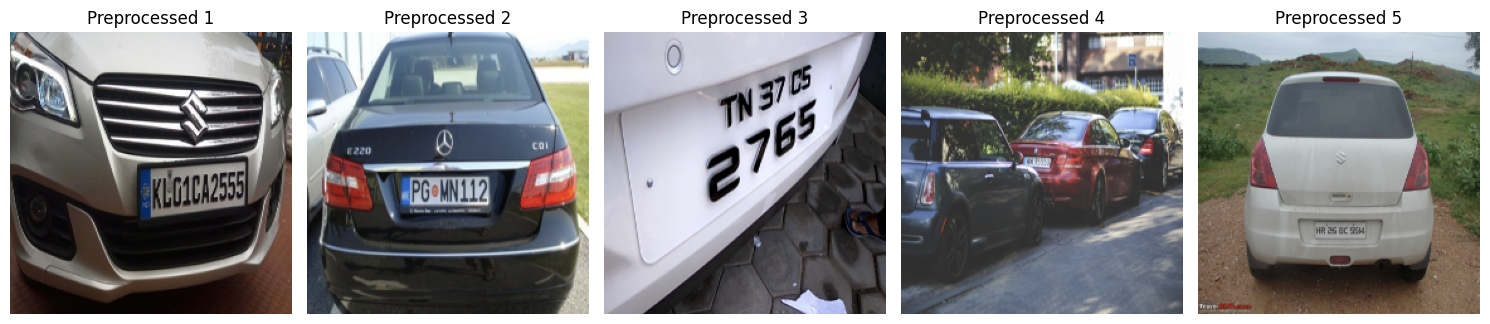

In [8]:
preprocessed_images = []
num_images_to_process = 10 # Process the first 10 images for demonstration

print(f"Processing {num_images_to_process} images...")

for i, img_path in enumerate(image_files[:num_images_to_process]):
    preprocessed_img = preprocess_image(img_path)
    if preprocessed_img is not None:
        preprocessed_images.append(preprocessed_img)
    else:
        print(f"Skipping {img_path} due to loading error.")

print(f"Successfully preprocessed {len(preprocessed_images)} images.")

# Display the first 5 preprocessed images
if len(preprocessed_images) > 0:
    plt.figure(figsize=(15, 5))
    for i, img_data in enumerate(preprocessed_images[:5]):
        plt.subplot(1, 5, i + 1)
        plt.imshow(img_data) # Normalized images are already in [0,1] float range
        plt.title(f"Preprocessed {i+1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No preprocessed images to display.")


## Understand XML Structure and Parse Bounding Box Data

Inspect the structure of an example XML annotation file. Write a Python function to parse these XML files and extract the bounding box coordinates for each object. This function will return the bounding box in a standardized format (e.g., [xmin, ymin, xmax, ymax]) and potentially the object class.


In [9]:
import os
import glob

# 1. Use os.listdir() to explore the contents of the dataset_root_path
print(f"Contents of {dataset_root_path}: {os.listdir(dataset_root_path)}")

# Assuming 'annotations' is the directory containing XML files
annotations_dir = os.path.join(dataset_root_path, 'annotations')
print(f"Annotations directory: {annotations_dir}")

# Get a list of all XML files in the annotations directory
xml_files = glob.glob(os.path.join(annotations_dir, '*.xml'))
xml_files.sort()

if len(xml_files) == 0:
    print("No XML annotation files found. Please check the directory structure.")
    example_xml_path = None
else:
    # 2. Select the first XML file as an example
    example_xml_path = xml_files[0]
    print(f"Example XML file: {example_xml_path}")

    # 3. Open and print the content of the example XML file
    print("\n--- Content of example XML file ---")
    with open(example_xml_path, 'r') as f:
        print(f.read())
    print("-----------------------------------")

Contents of /kaggle/input/car-plate-detection: ['annotations', 'images']
Annotations directory: /kaggle/input/car-plate-detection/annotations
Example XML file: /kaggle/input/car-plate-detection/annotations/Cars0.xml

--- Content of example XML file ---

<annotation>
    <folder>images</folder>
    <filename>Cars0.png</filename>
    <size>
        <width>500</width>
        <height>268</height>
        <depth>3</depth>
    </size>
    <segmented>0</segmented>
    <object>
        <name>licence</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>226</xmin>
            <ymin>125</ymin>
            <xmax>419</xmax>
            <ymax>173</ymax>
        </bndbox>
    </object>
</annotation>
-----------------------------------


**Reasoning**:
The next step is to implement the `parse_annotation` function using `xml.etree.ElementTree` to extract image dimensions and bounding box coordinates from the XML file, following the instructions provided.



In [10]:
import xml.etree.ElementTree as ET

def parse_annotation(xml_path):
    """
    Parses an XML annotation file to extract image dimensions and bounding box coordinates.

    Args:
        xml_path (str): The path to the XML annotation file.

    Returns:
        tuple: A tuple containing:
            - dict: Image dimensions {'width': int, 'height': int}.
            - list: A list of dictionaries, each containing 'name' (str) and 'bbox' (list of int).
                    Returns an empty list if no objects are found.
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Extract image dimensions
    size_tag = root.find('size')
    img_width = int(size_tag.find('width').text)
    img_height = int(size_tag.find('height').text)
    image_dims = {'width': img_width, 'height': img_height}

    # Extract bounding box data for each object
    objects = []
    for obj_tag in root.findall('object'):
        obj_name = obj_tag.find('name').text
        bndbox_tag = obj_tag.find('bndbox')
        xmin = int(bndbox_tag.find('xmin').text)
        ymin = int(bndbox_tag.find('ymin').text)
        xmax = int(bndbox_tag.find('xmax').text)
        ymax = int(bndbox_tag.find('ymax').text)
        objects.append({
            'name': obj_name,
            'bbox': [xmin, ymin, xmax, ymax]
        })
    return image_dims, objects

# Test the function with the example XML file
if example_xml_path:
    image_dimensions, detected_objects = parse_annotation(example_xml_path)
    print(f"\nImage Dimensions from XML: {image_dimensions}")
    print(f"Detected Objects from XML: {detected_objects}")
else:
    print("Cannot test parse_annotation function, example_xml_path is not defined.")

print("XML parsing function 'parse_annotation' defined and tested successfully.")


Image Dimensions from XML: {'width': 500, 'height': 268}
Detected Objects from XML: [{'name': 'licence', 'bbox': [226, 125, 419, 173]}]
XML parsing function 'parse_annotation' defined and tested successfully.


## Create Custom Dataset for Training

Develop a custom dataset class or generator that loads images and their corresponding parsed bounding box annotations. This class will handle loading images, applying the preprocessing function (defined earlier), and providing both the preprocessed image and its bounding box labels to the model.


In [11]:
data_samples = []

for xml_file_path in xml_files:
    try:
        # Construct the corresponding image path
        image_filename = os.path.basename(xml_file_path).replace('.xml', '.png')
        image_path = os.path.join(image_dir, image_filename)

        if not os.path.exists(image_path):
            print(f"Warning: Image not found for {xml_file_path}. Skipping.")
            continue

        # Parse the XML file to get image dimensions and bounding boxes
        image_dims, detected_objects = parse_annotation(xml_file_path)

        if not detected_objects:
            print(f"Warning: No objects found in {xml_file_path}. Skipping.")
            continue

        # Assuming only one 'licence' object per image for simplicity
        # In a real scenario, you might handle multiple objects or specific object types
        licence_bbox = None
        for obj in detected_objects:
            if obj['name'] == 'licence':
                licence_bbox = obj['bbox']
                break

        if licence_bbox is None:
            print(f"Warning: No 'licence' object found in {xml_file_path}. Skipping.")
            continue

        data_samples.append({
            'image_path': image_path,
            'raw_bbox': licence_bbox,
            'original_width': image_dims['width'],
            'original_height': image_dims['height']
        })

    except Exception as e:
        print(f"Error processing {xml_file_path}: {e}. Skipping.")

print(f"Prepared {len(data_samples)} data samples.")

# Display the first few samples to verify
for i, sample in enumerate(data_samples[:5]):
    print(f"Sample {i+1}: {sample}")


Prepared 433 data samples.
Sample 1: {'image_path': '/kaggle/input/car-plate-detection/images/Cars0.png', 'raw_bbox': [226, 125, 419, 173], 'original_width': 500, 'original_height': 268}
Sample 2: {'image_path': '/kaggle/input/car-plate-detection/images/Cars1.png', 'raw_bbox': [134, 128, 262, 160], 'original_width': 400, 'original_height': 248}
Sample 3: {'image_path': '/kaggle/input/car-plate-detection/images/Cars10.png', 'raw_bbox': [140, 5, 303, 148], 'original_width': 400, 'original_height': 225}
Sample 4: {'image_path': '/kaggle/input/car-plate-detection/images/Cars100.png', 'raw_bbox': [175, 114, 214, 131], 'original_width': 400, 'original_height': 267}
Sample 5: {'image_path': '/kaggle/input/car-plate-detection/images/Cars101.png', 'raw_bbox': [167, 202, 240, 220], 'original_width': 400, 'original_height': 300}


**Reasoning**:
Now that the `data_samples` list is prepared, I will define the custom Keras Sequence class `DetectionDataset` as instructed, which will handle image loading, preprocessing, and bounding box normalization.



In [12]:
import tensorflow as tf
import numpy as np # Already imported but good to be explicit for the context of this class

class DetectionDataset(tf.keras.utils.Sequence):
    def __init__(self, data_samples, target_size=(224, 224)):
        self.data_samples = data_samples
        self.target_size = target_size

    def __len__(self):
        return len(self.data_samples)

    def __getitem__(self, idx):
        sample = self.data_samples[idx]
        image_path = sample['image_path']
        raw_bbox = np.array(sample['raw_bbox'], dtype=np.float32)
        original_width = sample['original_width']
        original_height = sample['original_height']

        # Preprocess the image using the previously defined function
        preprocessed_img = preprocess_image(image_path, self.target_size)

        if preprocessed_img is None:
            # Handle error case, e.g., return a placeholder or raise an exception
            # For simplicity, we'll return a zero image and bbox for this example.
            # In a real scenario, you might filter out bad samples or handle them more robustly.
            print(f"Warning: Skipping sample {idx} due to image loading error.")
            return np.zeros((self.target_size[0], self.target_size[1], 3), dtype=np.float32), np.zeros(4, dtype=np.float32)

        # Normalize bounding box coordinates
        # xmin, ymin, xmax, ymax
        normalized_bbox = np.array([
            raw_bbox[0] / original_width, # xmin
            raw_bbox[1] / original_height, # ymin
            raw_bbox[2] / original_width, # xmax
            raw_bbox[3] / original_height # ymax
        ], dtype=np.float32)

        return preprocessed_img, normalized_bbox

print("Custom dataset class 'DetectionDataset' defined.")

# Instantiate and verify the custom dataset
# Using the target_size defined earlier (224, 224)

dataset_instance = DetectionDataset(data_samples, target_size=(224, 224))

print(f"Length of the dataset: {len(dataset_instance)} samples.")

# Fetch one sample to verify
image_sample, bbox_sample = dataset_instance[0]

print(f"Shape of preprocessed image sample: {image_sample.shape}")
print(f"Shape of normalized bounding box sample: {bbox_sample.shape}")
print(f"Normalized bounding box values: {bbox_sample}")
print(f"Normalized bounding box value range: [{bbox_sample.min():.4f}, {bbox_sample.max():.4f}]")


Custom dataset class 'DetectionDataset' defined.
Length of the dataset: 433 samples.
Shape of preprocessed image sample: (224, 224, 3)
Shape of normalized bounding box sample: (4,)
Normalized bounding box values: [0.452     0.4664179 0.838     0.6455224]
Normalized bounding box value range: [0.4520, 0.8380]


## Define and Prepare VGG-based CNN Model

Load a pre-trained VGG16 model (without its top classification layers) and add custom layers for bounding box regression. The model's output will be a 4-element vector representing the predicted bounding box coordinates.


In [13]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.models import Model

# 2. Define the input shape for the model
input_shape = (224, 224, 3) # Matches the target_size used for preprocessing

# 3. Load the pre-trained VGG16 model
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

# 4. Freeze the layers of the VGG16 base model
for layer in vgg_base.layers:
    layer.trainable = False

# 5. Create the new head for bounding box regression
x = vgg_base.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x) # Additional dense layer for feature extraction
x = Dense(64, activation='relu')(x)  # Another dense layer
output_bbox = Dense(4, activation='linear', name='bbox_output')(x) # 4 units for xmin, ymin, xmax, ymax

# 6. Construct the full model
model = Model(inputs=vgg_base.input, outputs=output_bbox)

# 7. Print the model summary
print("VGG-based CNN model for bounding box regression created.")
model.summary()

VGG-based CNN model for bounding box regression created.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bbox_output (Dense)             │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,934,596 (68.42 MB)

 Trainable params: 3,219,908 (12.28 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
from tensorflow.keras.optimizers import Adam

# 8. Compile the model
# Using Adam optimizer and Mean Squared Error (MSE) loss for bounding box regression
model.compile(optimizer=Adam(learning_rate=0.0001), loss='mean_squared_error', metrics=['mse'])

print("Model compiled successfully with Adam optimizer and Mean Squared Error loss.")

Model compiled successfully with Adam optimizer and Mean Squared Error loss.


## Compile and Train the Model

Implement a simplified training loop to train the model on the prepared dataset. Modify the training code to include an `EarlyStopping` callback. This callback will monitor `val_loss`, with a patience of 5 epochs, and will restore the best weights found during training. The number of epochs will be set higher (e.g., 50) to allow the early stopping mechanism to take effect.


**Reasoning**:
I will randomly select a few samples from the `val_samples` list, make predictions using the trained model, and then visualize both the predicted and ground truth bounding boxes on the original images.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


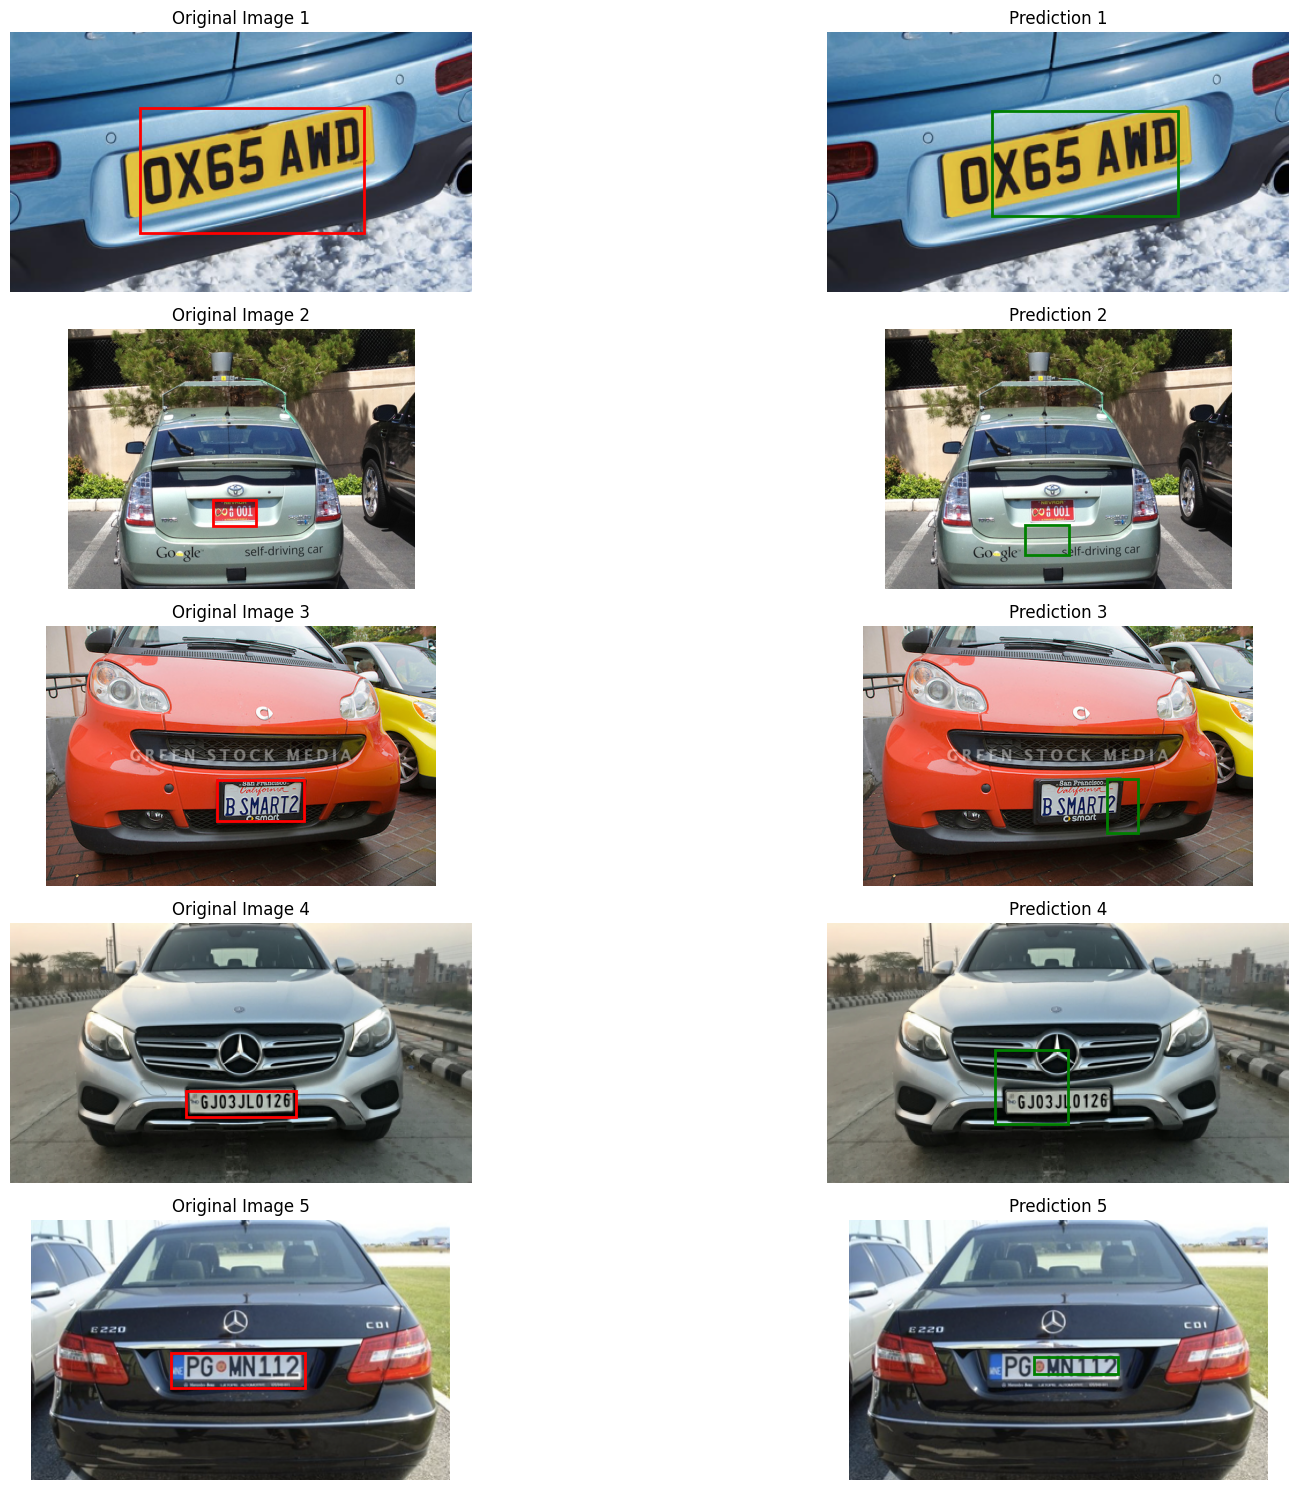

In [18]:
import random
import matplotlib.patches as patches

# Select a few random samples from the validation set for visualization
num_display = 5
random_indices = random.sample(range(len(val_samples)), num_display)

plt.figure(figsize=(20, 15))

for i, idx in enumerate(random_indices):
    sample = val_samples[idx]
    image_path = sample['image_path']
    true_bbox = sample['raw_bbox'] # Ground truth bounding box in original coordinates
    original_width = sample['original_width']
    original_height = sample['original_height']

    # Preprocess the image for model input
    preprocessed_img = preprocess_image(image_path) # Assumes preprocess_image is defined
    if preprocessed_img is None:
        print(f"Skipping {image_path} due to loading error.")
        continue

    # Add batch dimension for model prediction
    model_input = np.expand_dims(preprocessed_img, axis=0)

    # Get model prediction (normalized bbox)
    predicted_normalized_bbox = model.predict(model_input)[0]

    # Denormalize the predicted bounding box to original image coordinates
    pred_xmin = int(predicted_normalized_bbox[0] * original_width)
    pred_ymin = int(predicted_normalized_bbox[1] * original_height)
    pred_xmax = int(predicted_normalized_bbox[2] * original_width)
    pred_ymax = int(predicted_normalized_bbox[3] * original_height)
    predicted_bbox = [pred_xmin, pred_ymin, pred_xmax, pred_ymax]

    # Load the original image to draw on (OpenCV BGR, convert to RGB)
    original_img = cv2.imread(image_path)
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    ax = plt.subplot(num_display, 2, 2 * i + 1)
    ax.imshow(original_img_rgb)
    ax.set_title(f"Original Image {i+1}")
    ax.axis('off')

    # Draw ground truth bbox (red)
    rect_true = patches.Rectangle((true_bbox[0], true_bbox[1]), true_bbox[2] - true_bbox[0], true_bbox[3] - true_bbox[1], linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect_true)

    # Create a subplot for the prediction
    ax_pred = plt.subplot(num_display, 2, 2 * i + 2)
    ax_pred.imshow(original_img_rgb)
    ax_pred.set_title(f"Prediction {i+1}")
    ax_pred.axis('off')

    # Draw predicted bbox (green)
    rect_pred = patches.Rectangle((predicted_bbox[0], predicted_bbox[1]), predicted_bbox[2] - predicted_bbox[0], predicted_bbox[3] - predicted_bbox[1], linewidth=2, edgecolor='g', facecolor='none')
    ax_pred.add_patch(rect_pred)

plt.tight_layout()
plt.show()


In [16]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# 1. Split data_samples into training and validation sets
train_samples, val_samples = train_test_split(data_samples, test_size=0.2, random_state=42)

print(f"Number of training samples: {len(train_samples)}")
print(f"Number of validation samples: {len(val_samples)}")

# 2. Create instances of the DetectionDataset for both training and validation sets
train_dataset = DetectionDataset(train_samples, target_size=(224, 224))
val_dataset = DetectionDataset(val_samples, target_size=(224, 224))

# 3. Define a batch_size and update epochs
batch_size = 32
epochs = 50 # Number of training epochs, increased for early stopping

# 4. Instantiate EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Convert datasets to tf.data.Dataset for better performance and batching
train_data_tf = tf.data.Dataset.from_generator(
    lambda: (train_dataset[i] for i in range(len(train_dataset))),
    output_signature=(
        tf.TensorSpec(shape=(224, 224, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(4,), dtype=tf.float32)
    )
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_data_tf = tf.data.Dataset.from_generator(
    lambda: (val_dataset[i] for i in range(len(val_dataset))),
    output_signature=(
        tf.TensorSpec(shape=(224, 224, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(4,), dtype=tf.float32)
    )
).batch(batch_size).prefetch(tf.data.AUTOTUNE)


print("Starting model training with EarlyStopping...")
# 5. Train the model using the .fit() method with callbacks
history = model.fit(
    train_data_tf,
    epochs=epochs,
    validation_data=val_data_tf,
    callbacks=[early_stopping],
    verbose=1
)

print("Model training completed.")

Number of training samples: 346
Number of validation samples: 87
Starting model training with EarlyStopping...
Epoch 1/50
     11/Unknown 21s 2s/step - loss: 0.1556 - mse: 0.1556  

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


11/11 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - loss: 0.1522 - mse: 0.1522 - val_loss: 0.0681 - val_mse: 0.0681
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 640ms/step - loss: 0.0527 - mse: 0.0527 - val_loss: 0.0369 - val_mse: 0.0369
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 597ms/step - loss: 0.0269 - mse: 0.0269 - val_loss: 0.0242 - val_mse: 0.0242
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 606ms/step - loss: 0.0203 - mse: 0.0203 - val_loss: 0.0340 - val_mse: 0.0340
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 552ms/step - loss: 0.0227 - mse: 0.0227 - val_loss: 0.0215 - val_mse: 0.0215
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 605ms/step - loss: 0.0143 - mse: 0.0143 - val_loss: 0.0201 - val_mse: 0.0201
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 550ms/step - loss: 0.0081 - mse: 0.0081 - val_loss: 0.0193 - val_mse: 0.0193
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 599ms/step - loss: 0.0068 - mse: 0.0068 - val_loss: 0.0201 - val_mse: 0.0201
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 547ms/step - loss: 0.0057 - 

## Save Model and Print Weights

Save the trained model using `pickle` and print its final weights.

In [20]:
import pickle

# Define a filename for saving the model
model_filename = 'number_plate_detection_model.pkl'

# Save the trained model using pickle
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved successfully to {model_filename}")

# --- Optionally, load the model to verify and then print weights ---

# Load the model back (for verification or further use)
with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)

print("\nModel loaded successfully from disk.")

# Print the overall model summary to see the total weights
print("\nOverall Model Weights (Summary):")
loaded_model.summary()

print("\nTo see individual layer weights, you would iterate through loaded_model.get_weights() or examine individual layer weights.")

Model saved successfully to number_plate_detection_model.pkl

Model loaded successfully from disk.

Overall Model Weights (Summary):


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bbox_output (Dense)             │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,374,414 (92.98 MB)

 Trainable params: 3,219,908 (12.28 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 6,439,818 (24.57 MB)


To see individual layer weights, you would iterate through loaded_model.get_weights() or examine individual layer weights.


In [21]:
import os

model_filename = 'number_plate_detection_model.pkl'

# Get the size of the .pkl file in bytes
file_size_bytes = os.path.getsize(model_filename)

# Convert bytes to megabytes
file_size_mb = file_size_bytes / (1024 * 1024)

print(f"The size of '{model_filename}' is {file_size_mb:.2f} MB.")

The size of 'number_plate_detection_model.pkl' is 93.07 MB.
